# 5. Comparación final y discusión de resultados

**Objetivo:** integrar la estimación de $k$, la simulación RK4 y los errores de ajuste para comparar el comportamiento térmico de la casa de guadua y la casa de plástico.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

df = pd.read_csv(Path('datos_limpios.csv'))
df.head()

,muestra,tiempo_min,T_guadua,H_guadua,T_plastico,H_plastico,T_ambiente,H_ambiente
0,1,0,0.6,0.0,0.8,55.0,-2.4,10.0
1,2,1,24.1,55.0,25.5,60.0,20.1,63.0
2,3,2,24.3,55.0,25.9,60.0,20.1,63.0
3,4,3,24.2,55.0,25.1,60.0,20.1,63.0
4,5,4,24.4,55.0,25.2,60.0,20.0,63.0


## Consolidación de resultados

Se recalculan los parámetros dentro de este notebook para que el archivo sea autónomo y pueda correrse sin depender de variables previas.

In [3]:
def estimar_k_local(temperatura, ambiente, dt=1.0):
    temperatura = np.asarray(temperatura, dtype=float)
    ambiente = np.asarray(ambiente, dtype=float)
    delta_ambiente = temperatura[:-1] - ambiente[:-1]
    delta_temperatura = temperatura[1:] - temperatura[:-1]
    mascara = np.abs(delta_ambiente) > 1e-6
    k_local = -delta_temperatura[mascara] / (dt * delta_ambiente[mascara])
    k_local = k_local[np.isfinite(k_local)]
    k_local = k_local[(k_local > 0) & (k_local < 0.1)]
    return k_local

k_guadua = float(np.mean(estimar_k_local(df['T_guadua'], df['T_ambiente'])))
k_plastico = float(np.mean(estimar_k_local(df['T_plastico'], df['T_ambiente'])))

t_data = df['tiempo_min'].to_numpy(dtype=float)
tamb_data = df['T_ambiente'].to_numpy(dtype=float)
tamb_func = interp1d(t_data, tamb_data, kind='linear', fill_value='extrapolate')

def rk4_step(T, t, dt, tamb_func, k):
    def f(temperatura, tiempo):
        return -k * (temperatura - float(tamb_func(tiempo)))

    k1 = f(T, t)
    k2 = f(T + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(T + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(T + dt * k3, t + dt)
    return T + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

dt = 1.0
t_sim = np.arange(t_data[0], t_data[-1] + dt, dt)
T_guadua_sim = np.zeros_like(t_sim, dtype=float)
T_plastico_sim = np.zeros_like(t_sim, dtype=float)
T_guadua_sim[0] = df['T_guadua'].iloc[0]
T_plastico_sim[0] = df['T_plastico'].iloc[0]

for i in range(len(t_sim) - 1):
    T_guadua_sim[i + 1] = rk4_step(T_guadua_sim[i], t_sim[i], dt, tamb_func, k_guadua)
    T_plastico_sim[i + 1] = rk4_step(T_plastico_sim[i], t_sim[i], dt, tamb_func, k_plastico)

f_guadua_sim = interp1d(t_sim, T_guadua_sim, kind='linear')
f_plastico_sim = interp1d(t_sim, T_plastico_sim, kind='linear')
T_guadua_pred = f_guadua_sim(t_data)
T_plastico_pred = f_plastico_sim(t_data)

rmse_guadua = float(np.sqrt(np.mean((df['T_guadua'] - T_guadua_pred) ** 2)))
rmse_plastico = float(np.sqrt(np.mean((df['T_plastico'] - T_plastico_pred) ** 2)))

resumen = pd.DataFrame({
    'Material': ['Guadua', 'Plástico'],
    'k (1/min)': [k_guadua, k_plastico],
    'RMSE (°C)': [rmse_guadua, rmse_plastico]
}).round(6)

resumen

,Material,k (1/min),RMSE (°C)
0,Guadua,0.054529,3.729848
1,Plástico,0.049334,4.714153


## Visualización final

La siguiente figura resume la comparación entre medición real y simulación, y la tabla final deja explícitos los parámetros y el error de ajuste.

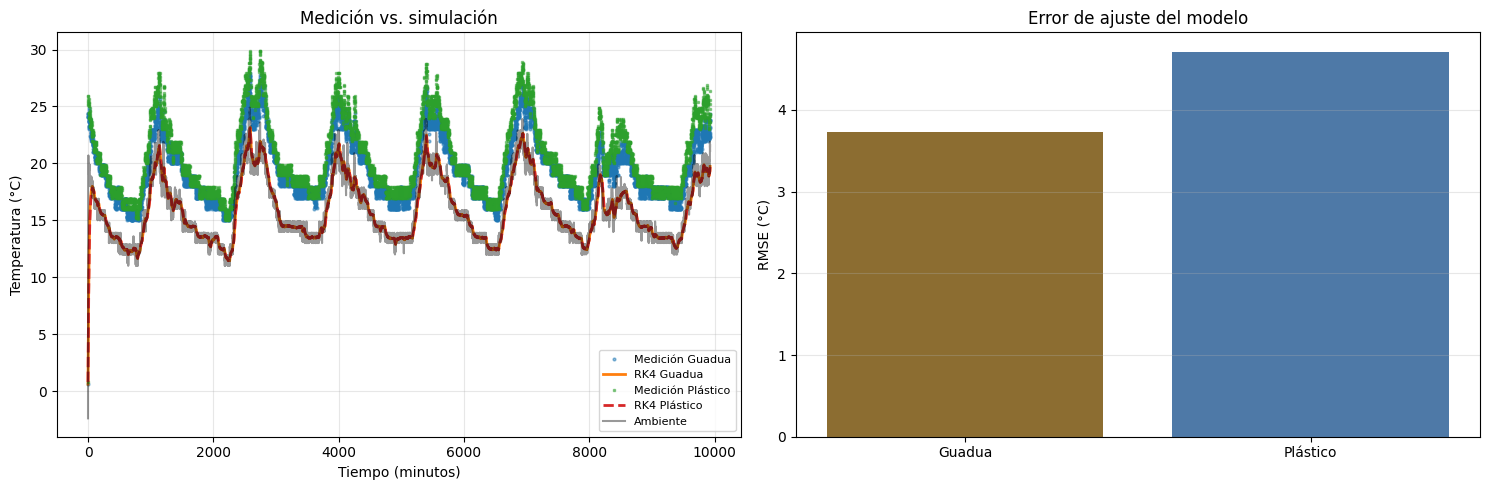

,Material,k (1/min),RMSE (°C)
0,Guadua,0.054529,3.729848
1,Plástico,0.049334,4.714153


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(df['tiempo_min'], df['T_guadua'], 'o', markersize=2, alpha=0.5, label='Medición Guadua')
axes[0].plot(t_sim, T_guadua_sim, '-', linewidth=2, label='RK4 Guadua')
axes[0].plot(df['tiempo_min'], df['T_plastico'], 's', markersize=2, alpha=0.5, label='Medición Plástico')
axes[0].plot(t_sim, T_plastico_sim, '--', linewidth=2, label='RK4 Plástico')
axes[0].plot(df['tiempo_min'], df['T_ambiente'], color='black', alpha=0.4, label='Ambiente')
axes[0].set_xlabel('Tiempo (minutos)')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Medición vs. simulación')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].bar(resumen['Material'], resumen['RMSE (°C)'], color=['#8c6d31', '#4e79a7'])
axes[1].set_ylabel('RMSE (°C)')
axes[1].set_title('Error de ajuste del modelo')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

resumen

## Discusión

- La casa de plástico responde más rápido a los cambios del ambiente, lo que se refleja en su valor de $k$ más alto.
- La casa de guadua muestra una respuesta más amortiguada, consistente con una menor tasa de intercambio térmico.
- El método RK4 reproduce la tendencia general de las mediciones y deja un error cuantificable mediante RMSE.

## Trabajo futuro

- Ajustar $k$ con optimización no lineal en lugar de promediar valores locales.
- Incluir la humedad en un modelo acoplado.
- Validar el modelo en otros tramos de datos o en nuevas campañas de medición.